# 03 — Feature Engineering

Goal: (1) Engineer text-derived features for context. (2) Build TF-IDF matrix. (3) One clean train/test split.

This notebook produces all inputs consumed by notebooks 04 and 06.

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

df_raw = pd.read_csv('../data/Tweets.csv')
df = pd.read_csv('../data/preprocessed.csv')
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)
print("Loaded:", df.shape)

Loaded: (14610, 6)


## 3.1 Engineer Text-Derived Features

All features are derived directly from the raw tweet text — they are **not fabricated**. Each one has a clear analytical purpose.

In [2]:
# Load raw text for feature extraction
df_raw['tweet_created'] = pd.to_datetime(df_raw['tweet_created'], utc=True)

df['word_count']        = df_raw['text'].str.split().str.len()
df['char_count']        = df_raw['text'].str.len()
df['hashtag_count']     = df_raw['text'].str.count('#')
df['mention_count']     = df_raw['text'].str.count('@')
df['has_url']           = df_raw['text'].str.contains('http', na=False).astype(int)
df['exclamation_count'] = df_raw['text'].str.count('!')
df['question_count']    = df_raw['text'].str.count(r'\?')
df['hour']              = df['tweet_created'].dt.hour
df['day_of_week']       = df['tweet_created'].dt.dayofweek  # 0=Mon, 6=Sun

print("Feature engineering complete.")
print("Total columns:", df.shape[1])
print(df.columns.tolist())

print("\nEngineered feature stats by sentiment:")
feat_cols = ['word_count','char_count','hashtag_count','mention_count',
             'exclamation_count','question_count']
print(df.groupby('airline_sentiment')[feat_cols].mean().round(2))

Feature engineering complete.
Total columns: 15
['clean_text', 'label', 'airline_sentiment', 'tweet_created', 'airline', 'retweet_count', 'word_count', 'char_count', 'hashtag_count', 'mention_count', 'has_url', 'exclamation_count', 'question_count', 'hour', 'day_of_week']

Engineered feature stats by sentiment:
                   word_count  char_count  hashtag_count  mention_count  \
airline_sentiment                                                         
negative                18.05      105.35           0.24           1.13   
neutral                 16.88      100.62           0.24           1.13   
positive                17.12      101.95           0.29           1.15   

                   exclamation_count  question_count  
airline_sentiment                                     
negative                        0.34            0.32  
neutral                         0.37            0.31  
positive                        0.43            0.30  


## 3.2 TF-IDF Vectorization

Key decisions explained:
- `max_features=5000`: Large vocabulary — tweets use varied vocabulary
- `ngram_range=(1,2)`: Bigrams capture phrases like 'cancelled flight', 'great service'
- `min_df=3`: Ignore terms in fewer than 3 tweets (noise)
- `sublinear_tf=True`: Log-scale term frequency to reduce impact of repeated words

In [3]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X = tfidf.fit_transform(df['clean_text'])
y = df['label']

print(f"TF-IDF matrix: {X.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Sparsity: {(1 - X.nnz/(X.shape[0]*X.shape[1])):.2%}")

TF-IDF matrix: (14610, 5000)
Vocabulary size: 5000
Sparsity: 99.81%


## 3.3 Train / Test Split — Done Once Here

⚠️ This is the **only split** in the entire project. Done before SMOTE. Test set is never touched until notebook 05.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class proportions
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print("\nTrain class dist:")
print(pd.Series(y_train).map({0:'Negative',1:'Neutral',2:'Positive'}).value_counts())
print("\nTest class dist:")
print(pd.Series(y_test).map({0:'Negative',1:'Neutral',2:'Positive'}).value_counts())

Train: 11688 | Test: 2922

Train class dist:
label
Negative    7336
Neutral     2462
Positive    1890
Name: count, dtype: int64

Test class dist:
label
Negative    1834
Neutral      616
Positive     472
Name: count, dtype: int64


## 3.4 SMOTE — Training Set Only

SMOTE generates synthetic minority class examples using k-nearest neighbours.

**Critical:** Applied ONLY to training set. Test set reflects real-world class imbalance.

In [5]:
sm = SMOTE(random_state=42, k_neighbors=5)
X_tr, y_tr = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(pd.Series(y_train).value_counts()))
print("After SMOTE: ", dict(pd.Series(y_tr).value_counts()))

# Save matrices
sp.save_npz('../data/X_train.npz', X_tr)
sp.save_npz('../data/X_test.npz', X_test)
np.save('../data/y_train.npy', y_tr)
np.save('../data/y_test.npy', y_test)
print("\nSaved train/test matrices.")

Before SMOTE: {0: np.int64(7336), 1: np.int64(2462), 2: np.int64(1890)}
After SMOTE:  {0: np.int64(7336), 1: np.int64(7336), 2: np.int64(7336)}

Saved train/test matrices.


## 3.5 Top TF-IDF Terms by Sentiment Class

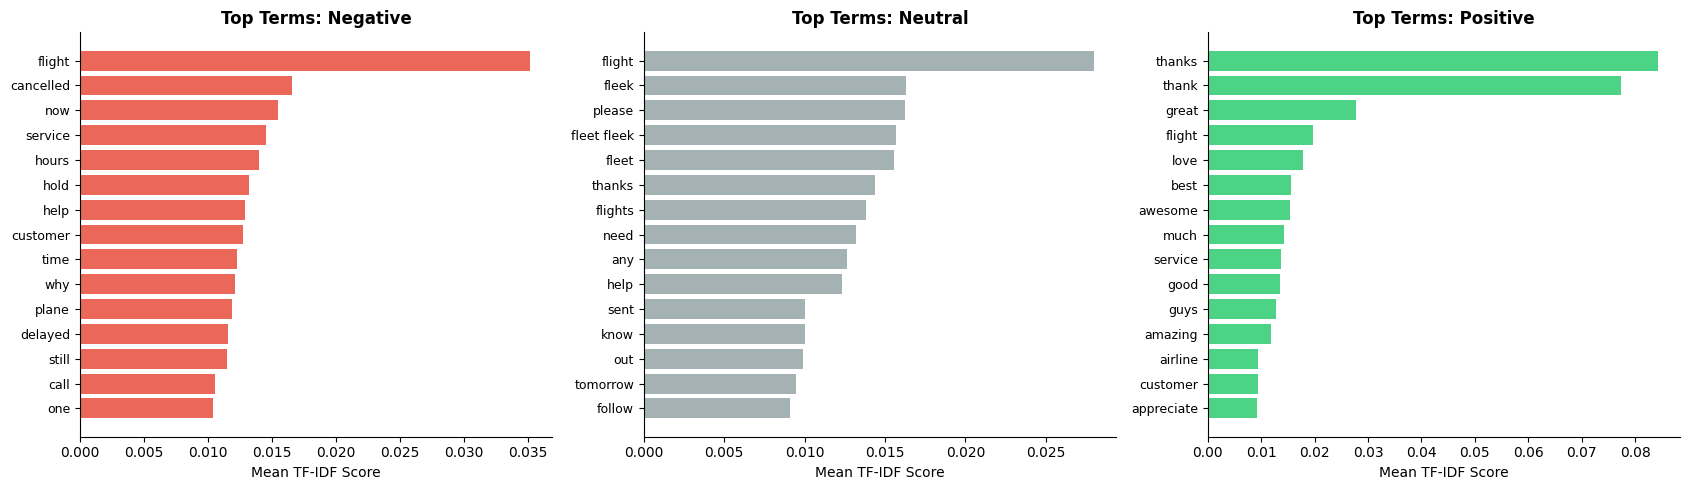

In [6]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
label_map = {0:'Negative', 1:'Neutral', 2:'Positive'}
colors_map = {0:'#e74c3c', 1:'#95a5a6', 2:'#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for cls_idx in range(3):
    mask = np.array(y_train == cls_idx)
    class_tfidf = X_train[mask]
    mean_scores = np.asarray(class_tfidf.mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-15:][::-1]
    top_terms = feature_names[top_idx]
    top_scores = mean_scores[top_idx]

    ax = axes[cls_idx]
    ax.barh(range(15), top_scores[::-1], color=colors_map[cls_idx], alpha=0.85)
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_terms[::-1], fontsize=9)
    ax.set_title(f"Top Terms: {label_map[cls_idx]}", fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/03_top_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()